# Practice — LSA and LDA Topic Modeling

In [2]:
%pip install gensim

Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
    --------------------------------------- 0.5/24.4 MB 1.8 MB/s eta 0:00:14
   -- ------------------------------------- 1.3/24.4 MB 3.3 MB/s eta 0:00:08
   --- ------------------------------------ 1.8/24.4 MB 2.8 MB/s eta 0:00:09
   --- ------------------------------------ 2.1/24.4 MB 2.7 MB/s eta 0:00:09
   --- ------------------------------------ 2.1/24.4 MB 2.7 MB/s eta 0:00:09
   --- ------------------------------------ 2.1/24.4 MB 2.7 MB/s eta 0:00:09
   --- ------------------------------------ 2.1/24.4 MB 2.7 MB/s eta 0:00:09
   --- ------------------------------------ 2.1/24.4 MB 2.7 MB/s eta 0:00:09
   ---- ----------------------------------- 2.9/24.4 MB 1.4 MB/s eta 0:00:16
   ---- ----------------------------------- 2.9/24.4 MB 1.4 MB/s eta 0:00:16
   ----- ---------------

In [3]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from gensim import corpora
from gensim.models import LsiModel
from gensim.models.coherencemodel import CoherenceModel
import gensim
import gensim.corpora as corpora
import matplotlib.pyplot as plt

### Load Data

In [19]:
data = pd.read_csv("106 - tripadvisor-hotel-reviews.csv") # data should be in the same folder as your notebook

In [20]:
data.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  109 non-null    object
 1   Rating  109 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ KB


### Clean Data

In [21]:
# TODO: take just the content of the article, lowercase and remove punctuation
articles = data["Review"].str.lower().apply(lambda x: re.sub(r"\*", " star", x))
articles = articles.apply(lambda x: re.sub("[^\w\s]","",x))
articles

0      nice hotel expensive parking got good deal sta...
1      ok nothing special charge diamond member hilto...
2      nice rooms not 4 star experience hotel monaco ...
3      unique great stay wonderful time hotel monaco ...
4      great stay great stay went seahawk game awesom...
                             ...                        
104    fairmont hotel singapore splendid stayed fairm...
105    great hotel stayed hotel night route perth chr...
106    great hotel centre stayed 5 nights room overlo...
107    great location great value great hotel husband...
108    lovely hotel great location stayed vacation to...
Name: Review, Length: 109, dtype: object

In [23]:
# TODO: stop word removal
en_stopwords = stopwords.words("english")
print(en_stopwords)
articles = articles.apply(lambda x: " ".join(words for words in x.split() if words not in en_stopwords))
articles

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

0      nice hotel expensive parking got good deal sta...
1      ok nothing special charge diamond member hilto...
2      nice rooms 4 star experience hotel monaco seat...
3      unique great stay wonderful time hotel monaco ...
4      great stay great stay went seahawk game awesom...
                             ...                        
104    fairmont hotel singapore splendid stayed fairm...
105    great hotel stayed hotel night route perth chr...
106    great hotel centre stayed 5 nights room overlo...
107    great location great value great hotel husband...
108    lovely hotel great location stayed vacation to...
Name: Review, Length: 109, dtype: object

In [24]:
# TODO: tokenize
articles = articles.apply(lambda x: word_tokenize(x))
articles

0      [nice, hotel, expensive, parking, got, good, d...
1      [ok, nothing, special, charge, diamond, member...
2      [nice, rooms, 4, star, experience, hotel, mona...
3      [unique, great, stay, wonderful, time, hotel, ...
4      [great, stay, great, stay, went, seahawk, game...
                             ...                        
104    [fairmont, hotel, singapore, splendid, stayed,...
105    [great, hotel, stayed, hotel, night, route, pe...
106    [great, hotel, centre, stayed, 5, nights, room...
107    [great, location, great, value, great, hotel, ...
108    [lovely, hotel, great, location, stayed, vacat...
Name: Review, Length: 109, dtype: object

In [26]:
# TODO: stemming (done for speed as we have a lot of text)
ps = PorterStemmer()
articles = articles.apply(lambda x: [ps.stem(word) for word in x])

In [27]:
articles

0      [nice, hotel, expen, park, got, good, deal, st...
1      [ok, noth, special, charg, diamond, member, hi...
2      [nice, room, 4, star, experi, hotel, monaco, s...
3      [uniqu, great, stay, wonder, time, hotel, mona...
4      [great, stay, great, stay, went, seahawk, game...
                             ...                        
104    [fairmont, hotel, singapor, splendid, stay, fa...
105    [great, hotel, stay, hotel, night, rout, perth...
106    [great, hotel, centr, stay, 5, night, room, ov...
107    [great, locat, great, valu, great, hotel, husb...
108    [love, hotel, great, locat, stay, vacat, tour,...
Name: Review, Length: 109, dtype: object

### Vectorization

In [28]:
# TODO: create dictionary of all words
dictionary = corpora.Dictionary(articles)
print(dictionary)

Dictionary<2269 unique tokens: ['40', 'advantag', 'advic', 'anniversari', 'arriv']...>


In [29]:
# TODO: vectorize using bag of words into a document term matrix
# Hint: [dictionary.doc2bow(text) for text in articles]
doc_term = [dictionary.doc2bow(text) for text in articles]

In [30]:
print(doc_term)

[[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 2), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1), (41, 5), (42, 2), (43, 1), (44, 1), (45, 1), (46, 1), (47, 3), (48, 1), (49, 1), (50, 1), (51, 1), (52, 1), (53, 1), (54, 1), (55, 3), (56, 1), (57, 1), (58, 1), (59, 3), (60, 1), (61, 1), (62, 1), (63, 1), (64, 1), (65, 1), (66, 1), (67, 1), (68, 1)], [(3, 2), (4, 4), (8, 1), (10, 1), (22, 4), (23, 3), (24, 1), (28, 2), (29, 7), (30, 1), (31, 2), (37, 1), (41, 1), (42, 2), (50, 2), (55, 6), (56, 1), (59, 1), (63, 1), (66, 1), (69, 1), (70, 1), (71, 1), (72, 2), (73, 3), (74, 1), (75, 1), (76, 2), (77, 1), (78, 2), (79, 1), (80, 1), (81, 2), (82, 2), (83, 1), (84, 1), (85, 2), (86, 1), (87, 1), (88, 1), (89, 3), (90, 1), (91, 1), (

### LSA

In [31]:
# specify number of topics
num_topics = 2

In [32]:
# TODO: create LSA model
lsamodel = gensim.models.LsiModel(corpus = doc_term , id2word= dictionary, num_topics= num_topics)
print(lsamodel.print_topics(num_topics=num_topics, num_words=5))

[(0, '-0.494*"hotel" + -0.479*"room" + -0.249*"stay" + -0.174*"great" + -0.160*"nt"'), (1, '-0.436*"hotel" + 0.368*"room" + 0.237*"bed" + -0.215*"great" + -0.151*"locat"')]


### Determine Number of Topics

In [33]:
# generate coherence scores to determine an optimum number of topics
coherence_values = []
model_list = []

min_topics = 2
max_topics = 11

# TODO: loop through num_topics_i from min_topics to max_topics (inclusive)
# For each: create an LsiModel, append it to model_list, compute coherence with
# CoherenceModel(model=model, texts=articles, dictionary=dictionary, coherence='c_v')
# and append the coherence score to coherence_values
for num_topics_i in range(min_topics, max_topics+1):
    lsa_model = gensim.models.LsiModel(corpus = doc_term, num_topics= num_topics_i, id2word= dictionary)
    model_list.append(lsa_model)
    coherence_model = gensim.models.CoherenceModel(model = lsa_model,texts = articles, dictionary= dictionary, coherence= "c_v")
    coherence_values.append(coherence_model.get_coherence())
    

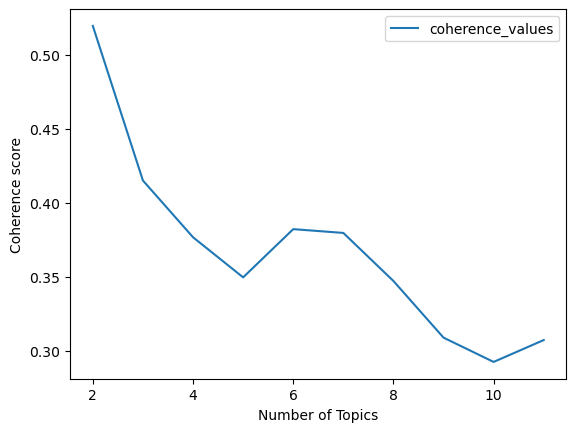

In [35]:
plt.plot(range(min_topics, max_topics+1), coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values",), loc='best')
plt.show()

In [36]:
# TODO: pick a final number of topics based on the coherence plot above and build the final LSA model
final_n_topics = 2
lsamodel_f = gensim.models.LsiModel(corpus = doc_term, num_topics= final_n_topics, id2word= dictionary)
print(lsamodel_f.print_topics(num_topics=final_n_topics, num_words=5))

[(0, '-0.494*"hotel" + -0.479*"room" + -0.249*"stay" + -0.174*"great" + -0.160*"nt"'), (1, '0.436*"hotel" + -0.368*"room" + -0.237*"bed" + 0.215*"great" + 0.151*"locat"')]


### LDA

In [37]:
# specify number of topics
num_topics = 2

In [38]:
# TODO: create LDA model
# Hint: gensim.models.LdaModel(corpus=doc_term, id2word=dictionary, num_topics=num_topics)
lda_model = gensim.models.LdaModel(corpus= doc_term, num_topics= num_topics, id2word= dictionary )

In [39]:
lda_model.print_topics(num_topics=num_topics, num_words=5)

[(0,
  '0.028*"room" + 0.020*"hotel" + 0.017*"stay" + 0.012*"great" + 0.010*"seattl"'),
 (1,
  '0.032*"hotel" + 0.019*"room" + 0.011*"stay" + 0.010*"great" + 0.009*"nt"')]